# Capítulo 6 — PSF Variable en el Campo (Space-Variant Imaging)

En todos los capítulos anteriores asumimos que la PSF era **igual en toda la imagen**
— esto se llama sistema **espacio-invariante** (Space-Invariant, SI).

En la realidad, la PSF **cambia con la posición** en el plano de imagen:

| Sistema | Causa de la variabilidad |
|---|---|
| Telescopio de campo amplio | Aberraciones de campo (coma, astigmatismo crecen con el ángulo) |
| Microscopio de fluorescencia | Variación del índice de refracción de la muestra |
| Cámara con lente barata | Distorsión y aberración cromática en los bordes |
| Imagen atmosférica (AO) | Turbulencia espacialmente correlada pero no uniforme |
| Escáner médico (MRI, CT) | Gradiente del campo magnético produce PSF variable |

Esto se llama sistema **espacio-variante** (Space-Variant, SV) y hace que el
modelo de convolución clásico **ya no sea válido**:

$$
g(x,y) = \int\int f(x', y') \cdot h(x, y; x', y') \, dx'\, dy'
$$

donde $h(x, y; x', y')$ depende **tanto de la posición de la fuente** $(x', y')$
**como de la posición de observación** $(x, y)$.

---

### Contenido

1. Modelo matemático de sistemas espacio-variantes  
2. Generación de campos de PSF: interpolación suave  
3. Degradación espacio-variante eficiente (sector-based)  
4. Restauración local: dividir en regiones y reconvolucionar  
5. Restauración por interpolación de filtros de Wiener  
6. Red neuronal para restauración SV (U-Net con campo de PSF como entrada)  
7. Estimación del campo de PSF desde la imagen  
8. Caso de uso: corrección de aberraciones en campo amplio  
9. Ejercicios sugeridos  
10. Conclusiones  


## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates
from skimage import data as skdata
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✔ PyTorch {torch.__version__} | dispositivo: {device}")
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠ PyTorch no disponible.")

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["image.cmap"]     = "gray"
np.random.seed(42)

# ── Imagen de referencia ──────────────────────────────────────────────────
img = skdata.camera().astype(np.float64)[:256, :256] / 255.0
H, W = img.shape
print(f"Imagen de trabajo: {img.shape}")


✔ PyTorch 2.11.0+cu128 | dispositivo: cuda
Imagen de trabajo: (256, 256)


## 1. Modelo matemático de sistemas espacio-variantes

### 1.1 De la convolución al operador integral general

Un sistema lineal espacio-invariante satisface:

$$
g(x,y) = (f \otimes h)(x,y) = \iint f(x',y') \, h(x-x', y-y') \, dx'dy'
$$

La PSF $h(x-x', y-y')$ solo depende de la **diferencia** de posiciones.

Un sistema espacio-variante tiene una PSF más general $h(x,y;x',y')$:

$$
g(x,y) = \iint f(x',y') \, h(x,y;x',y') \, dx'dy'
$$

Esto es mucho más complejo: no se puede aplicar directamente la FFT,
ya que el Teorema de la Convolución no aplica.

### 1.2 La aproximación local (Locally Space-Invariant)

La aproximación más usada en la práctica es asumir que la PSF varía
**suavemente** con la posición, de modo que en una región pequeña
alrededor de $(x_0, y_0)$ el sistema se comporta como SI:

$$
h(x, y; x', y') \approx h_{(x_0,y_0)}(x-x', y-y')
$$

Esto permite dividir la imagen en **sectores** y aplicar convolución
SI en cada uno, luego mezclar los resultados suavemente.

### 1.3 Modelos paramétricos del campo de PSF

El campo de PSF $h_{(x,y)}$ se puede parametrizar de varias formas:

| Modelo | Parámetro | Uso típico |
|---|---|---|
| Gaussiana isotrópica variable | $\sigma(x,y)$ | Primer orden, fácil de estimar |
| Gaussiana anisotrópica | $\sigma_x(x,y), \sigma_y(x,y), \theta(x,y)$ | Astigmatismo variable |
| Combinación lineal de PSFs base | $w_k(x,y)$ | Método general (eigenPSF) |
| Red neuronal | Pesos de la red | Máxima flexibilidad |


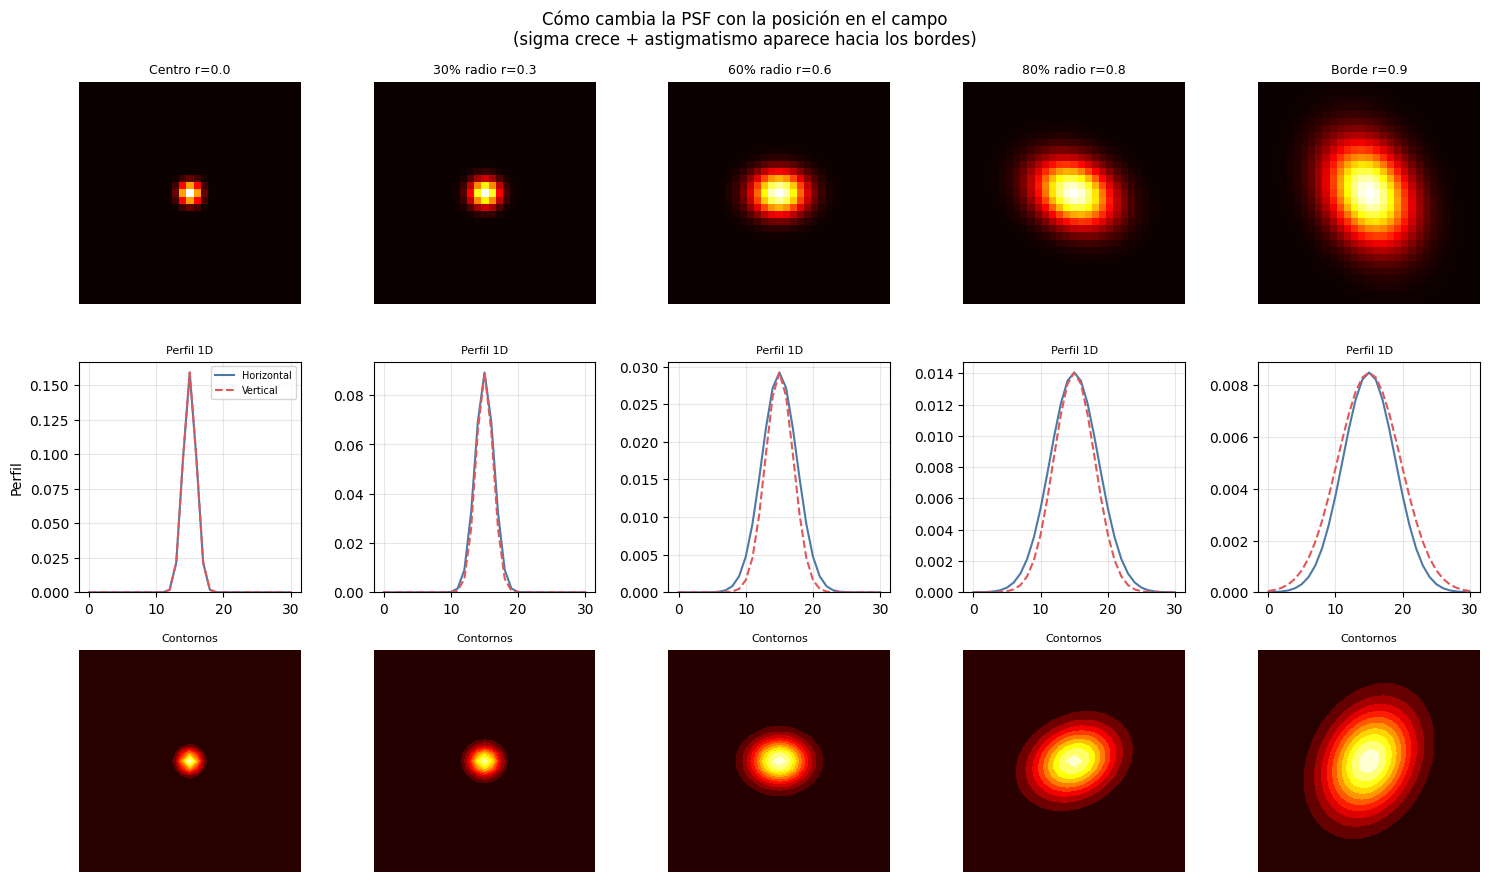

In [2]:
# ── Visualizar el concepto: PSF cambia con la posición ────────────────────
def gaussian_psf_2d(sigma_x, sigma_y, theta_deg=0, size=31):
    """PSF gaussiana anisotrópica orientada."""
    ax = np.linspace(-(size//2), size//2, size)
    XX, YY = np.meshgrid(ax, ax)
    theta = np.deg2rad(theta_deg)
    Xr =  XX*np.cos(theta) + YY*np.sin(theta)
    Yr = -XX*np.sin(theta) + YY*np.cos(theta)
    h = np.exp(-0.5*((Xr/sigma_x)**2 + (Yr/sigma_y)**2))
    return h / h.sum()

# Mostrar cómo cambia la PSF en distintas posiciones del campo
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Posiciones en el campo (en fracción del radio máximo)
positions = [(0,0), (0.3,0), (0.6,0), (0.8,0.3), (0.95,0.7)]
pos_labels = ["Centro", "30% radio", "60% radio", "80% radio", "Borde"]

for col, (r, phi_frac), label in zip(range(5), positions, pos_labels):
    # Simular aberración de campo: sigma crece, astigmatismo aparece con el ángulo
    sigma_core = 1.0 + 3.0 * r**2          # PSF crece cuadráticamente
    astig      = 1.5 * r**2                  # astigmatismo crece con r²
    angle      = phi_frac * 90              # orientación varía

    h_center = gaussian_psf_2d(sigma_core, sigma_core, 0)
    h_edge   = gaussian_psf_2d(sigma_core + astig, sigma_core, angle)

    psf_show = h_edge if r > 0 else h_center

    # Vista 2D
    axes[0, col].imshow(psf_show, cmap="hot")
    axes[0, col].set_title(f"{label} r={r:.1f}", fontsize=9)
    axes[0, col].axis("off")

    # Perfil central X e Y superpuestos
    mid = psf_show.shape[0]//2
    axes[1, col].plot(psf_show[mid, :], label="Horizontal", color="#4e79a7")
    axes[1, col].plot(psf_show[:, mid], label="Vertical",   color="#e15759", linestyle="--")
    if col == 0: axes[1, col].legend(fontsize=7)
    axes[1, col].set_title("Perfil 1D", fontsize=8)
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set_ylim(0, None)

    # Mapa de calor 3D simplificado (superficie)
    axes[2, col].contourf(psf_show, levels=12, cmap="hot")
    axes[2, col].set_aspect("equal")
    axes[2, col].axis("off")
    axes[2, col].set_title("Contornos", fontsize=8)

axes[0, 0].set_ylabel("PSF 2D", fontsize=10)
axes[1, 0].set_ylabel("Perfil", fontsize=10)
axes[2, 0].set_ylabel("Contornos", fontsize=10)

plt.suptitle("Cómo cambia la PSF con la posición en el campo\n"
             "(sigma crece + astigmatismo aparece hacia los bordes)", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Generación de campos de PSF: interpolación suave

Para trabajar con sistemas SV necesitamos representar el **campo de PSF**:
la función $h_{(x,y)}$ que asigna una PSF a cada posición del plano imagen.

En la práctica se hace así:

1. Se **mide o simula** la PSF en un grid de posiciones $(x_k, y_k)$
2. Se **interpola** suavemente entre esas posiciones para obtener
   la PSF en cualquier punto intermedio

Modelamos tres tipos de aberración de campo comunes:

### Defocus variable con el campo
$\sigma(x,y) = \sigma_0 + a \cdot r^2$ donde $r = \sqrt{(x/W)^2 + (y/H)^2}$

### Astigmatismo variable
La PSF se vuelve elíptica y su eje rota con la posición angular

### Coma
Genera una cola asimétrica cuya dirección apunta al centro del campo


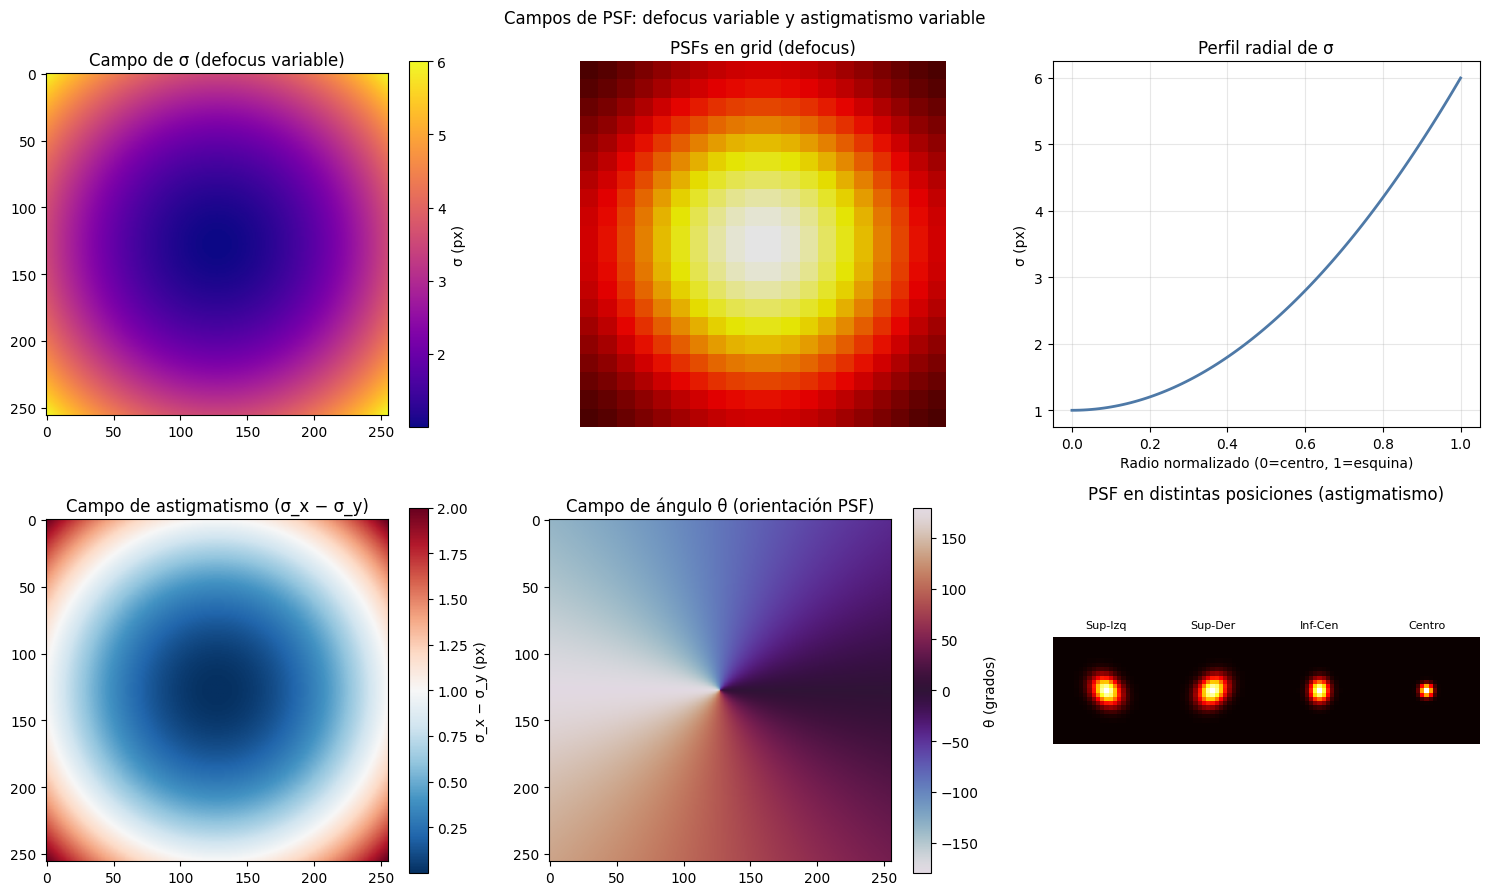

In [4]:
# ── Campo de sigma (defocus variable) ────────────────────────────────────
def sigma_field(H, W, sigma_center=1.0, sigma_edge=5.0, power=2):
    """Genera un campo de sigma que crece del centro al borde."""
    y = np.linspace(-1, 1, H)
    x = np.linspace(-1, 1, W)
    XX, YY = np.meshgrid(x, y)
    R = np.sqrt(XX**2 + YY**2) / np.sqrt(2)   # normalizar a [0,1] en esquina
    R = np.clip(R, 0, 1)
    return sigma_center + (sigma_edge - sigma_center) * R**power

# Generar el campo
sig_field = sigma_field(H, W, sigma_center=1.0, sigma_edge=6.0, power=2)

# ── Campo de astigmatismo (sigma_x, sigma_y, theta variables) ─────────────
def astig_field(H, W):
    """Genera campos de sigma_x, sigma_y, theta para astigmatismo variable."""
    y = np.linspace(-1, 1, H)
    x = np.linspace(-1, 1, W)
    XX, YY = np.meshgrid(x, y)
    R     = np.sqrt(XX**2 + YY**2) / np.sqrt(2)
    theta = np.arctan2(YY, XX)  # ángulo polar

    sigma_mean = 1.0 + 4.0 * R**2
    astig_amp  = 2.0 * R**2
    sigma_x    = sigma_mean + astig_amp
    sigma_y    = sigma_mean
    angle_deg  = np.rad2deg(theta)    # PSF orientada radialmente
    return sigma_x, sigma_y, angle_deg

sig_x_field, sig_y_field, angle_field = astig_field(H, W)

# ── Visualización de los campos ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Fila 0: campo de defocus
im0 = axes[0,0].imshow(sig_field, cmap="plasma")
axes[0,0].set_title("Campo de σ (defocus variable)")
plt.colorbar(im0, ax=axes[0,0], label="σ (px)")

# PSF en grid 5×5
grid_y = np.linspace(20, H-20, 5, dtype=int)
grid_x = np.linspace(20, W-20, 5, dtype=int)
ax_psf = axes[0,1]
ax_psf.imshow(np.zeros((H,W)), vmin=0, vmax=1, cmap="gray")
ax_psf.set_title("PSFs en grid (defocus)")

for gy in grid_y:
    for gx in grid_x:
        s = sig_field[gy, gx]
        psf_mini = gaussian_psf_2d(s, s, size=15)
        # Escalar para visualización
        size_disp = 20
        half = size_disp//2
        ry0,ry1 = gy-half, gy+half
        rx0,rx1 = gx-half, gx+half
        if 0<=ry0 and ry1<=H and 0<=rx0 and rx1<=W:
            from skimage.transform import resize
            psf_resized = resize(psf_mini, (size_disp, size_disp), anti_aliasing=True)
            ax_psf.imshow(psf_resized, extent=[rx0,rx1,ry1,ry0],
                         cmap="hot", alpha=0.9, vmin=0, vmax=psf_resized.max())
ax_psf.axis("off")

# Perfil radial de sigma
r_line = np.linspace(0, 1, 100)
sigma_line = 1.0 + (6.0-1.0)*r_line**2
axes[0,2].plot(r_line, sigma_line, color="#4e79a7", linewidth=2)
axes[0,2].set_xlabel("Radio normalizado (0=centro, 1=esquina)")
axes[0,2].set_ylabel("σ (px)")
axes[0,2].set_title("Perfil radial de σ")
axes[0,2].grid(True, alpha=0.3)

# Fila 1: campo de astigmatismo
im1 = axes[1,0].imshow(sig_x_field - sig_y_field, cmap="RdBu_r")
axes[1,0].set_title("Campo de astigmatismo (σ_x − σ_y)")
plt.colorbar(im1, ax=axes[1,0], label="σ_x − σ_y (px)")

im2 = axes[1,1].imshow(angle_field, cmap="twilight")
axes[1,1].set_title("Campo de ángulo θ (orientación PSF)")
plt.colorbar(im2, ax=axes[1,1], label="θ (grados)")

# PSF en algunos puntos clave
positions_demo = [(H//4, W//4), (H//4, 3*W//4), (3*H//4, W//2), (H//2, W//2)]
labels_demo    = ["Sup-Izq", "Sup-Der", "Inf-Cen", "Centro"]
psf_examples   = []
for (py, px), lbl in zip(positions_demo, labels_demo):
    sx = sig_x_field[py, px]
    sy = sig_y_field[py, px]
    an = angle_field[py, px]
    psf_ex = gaussian_psf_2d(sx, sy, an, size=25)
    psf_examples.append((psf_ex, lbl))

n = len(psf_examples)
for i, (psf_ex, lbl) in enumerate(psf_examples):
    inset = axes[1,2].inset_axes([i/n, 0, 1/n, 1])
    inset.imshow(psf_ex, cmap="hot")
    inset.set_title(lbl, fontsize=8)
    inset.axis("off")
axes[1,2].axis("off")
axes[1,2].set_title("PSF en distintas posiciones (astigmatismo)")

plt.suptitle("Campos de PSF: defocus variable y astigmatismo variable", fontsize=12)
plt.tight_layout()
plt.show()


## 3. Degradación espacio-variante eficiente (sector-based)

La forma exacta de aplicar una degradación SV es computacionalmente costosa:
requeriría una convolución diferente para cada píxel.

La aproximación práctica más usada es el **método por sectores**:

1. Dividir la imagen en $S \times S$ sectores solapados
2. En cada sector, aplicar la PSF **local** (convolución SI)
3. Mezclar los resultados con ventanas de ponderación suave (Hann, Gaussiana)
   para evitar artefactos en los bordes entre sectores

La suavidad del campo de PSF garantiza que la mezcla sea coherente.


Aplicando degradación espacio-variante...


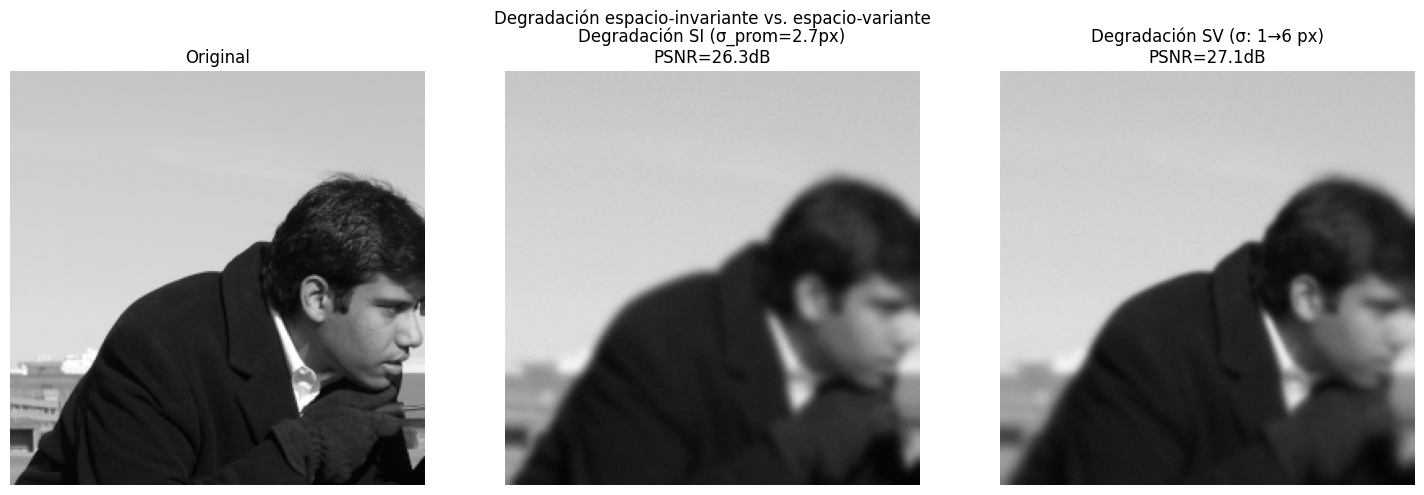

Observa: en la imagen SV, el centro está más nítido que los bordes.


In [5]:
def sv_degrade(f, sigma_field_map, psf_size=25, n_sectors=6, sigma_n=0.005):
    """
    Degradación espacio-variante por sectores solapados.
    
    Para cada sector: calcula la PSF promedio del sector, convolucia,
    y mezcla con ventana de coseno.
    """
    M, N = f.shape
    result = np.zeros_like(f)
    weight = np.zeros_like(f)

    # Crear grid de centros de sector
    ys = np.linspace(0, M-1, n_sectors+1, dtype=int)
    xs = np.linspace(0, N-1, n_sectors+1, dtype=int)

    for i in range(n_sectors):
        for j in range(n_sectors):
            # Centro del sector
            cy = (ys[i] + ys[i+1]) // 2
            cx = (xs[j] + xs[j+1]) // 2

            # PSF del sector: sigma promedio en el sector
            y0, y1 = max(0, ys[i]-psf_size), min(M, ys[i+1]+psf_size)
            x0, x1 = max(0, xs[j]-psf_size), min(N, xs[j+1]+psf_size)
            sigma_local = sigma_field_map[cy, cx]
            h_local = gaussian_psf_2d(sigma_local, sigma_local, size=psf_size)

            # Convolucionar imagen completa con PSF local
            f_blurred = convolve2d(f, h_local, mode='same', boundary='symm')

            # Ventana de ponderación suave (gaussiana centrada en el sector)
            win_y = np.exp(-0.5*((np.arange(M)-cy)/(M/n_sectors*0.7))**2)
            win_x = np.exp(-0.5*((np.arange(N)-cx)/(N/n_sectors*0.7))**2)
            win   = np.outer(win_y, win_x)

            result += f_blurred * win
            weight += win

    # Normalizar por los pesos
    result /= np.maximum(weight, 1e-10)
    # Agregar ruido
    result = np.clip(result + np.random.normal(0, sigma_n, f.shape), 0, 1)
    return result

print("Aplicando degradación espacio-variante...")
g_sv = sv_degrade(img, sig_field, psf_size=25, n_sectors=6, sigma_n=0.005)

# Comparar con degradación SI usando sigma promedio
sigma_mean = sig_field.mean()
h_mean = gaussian_psf_2d(sigma_mean, sigma_mean, size=25)
g_si = np.clip(convolve2d(img, h_mean, mode='same', boundary='symm') +
               np.random.normal(0, 0.005, img.shape), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, vmin=0, vmax=1); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(g_si, vmin=0, vmax=1)
axes[1].set_title(f"Degradación SI (σ_prom={sigma_mean:.1f}px)\nPSNR={psnr(img,g_si,data_range=1):.1f}dB")
axes[1].axis("off")
axes[2].imshow(g_sv, vmin=0, vmax=1)
axes[2].set_title(f"Degradación SV (σ: 1→6 px)\nPSNR={psnr(img,g_sv,data_range=1):.1f}dB")
axes[2].axis("off")
plt.suptitle("Degradación espacio-invariante vs. espacio-variante", fontsize=12)
plt.tight_layout()
plt.show()
print("Observa: en la imagen SV, el centro está más nítido que los bordes.")


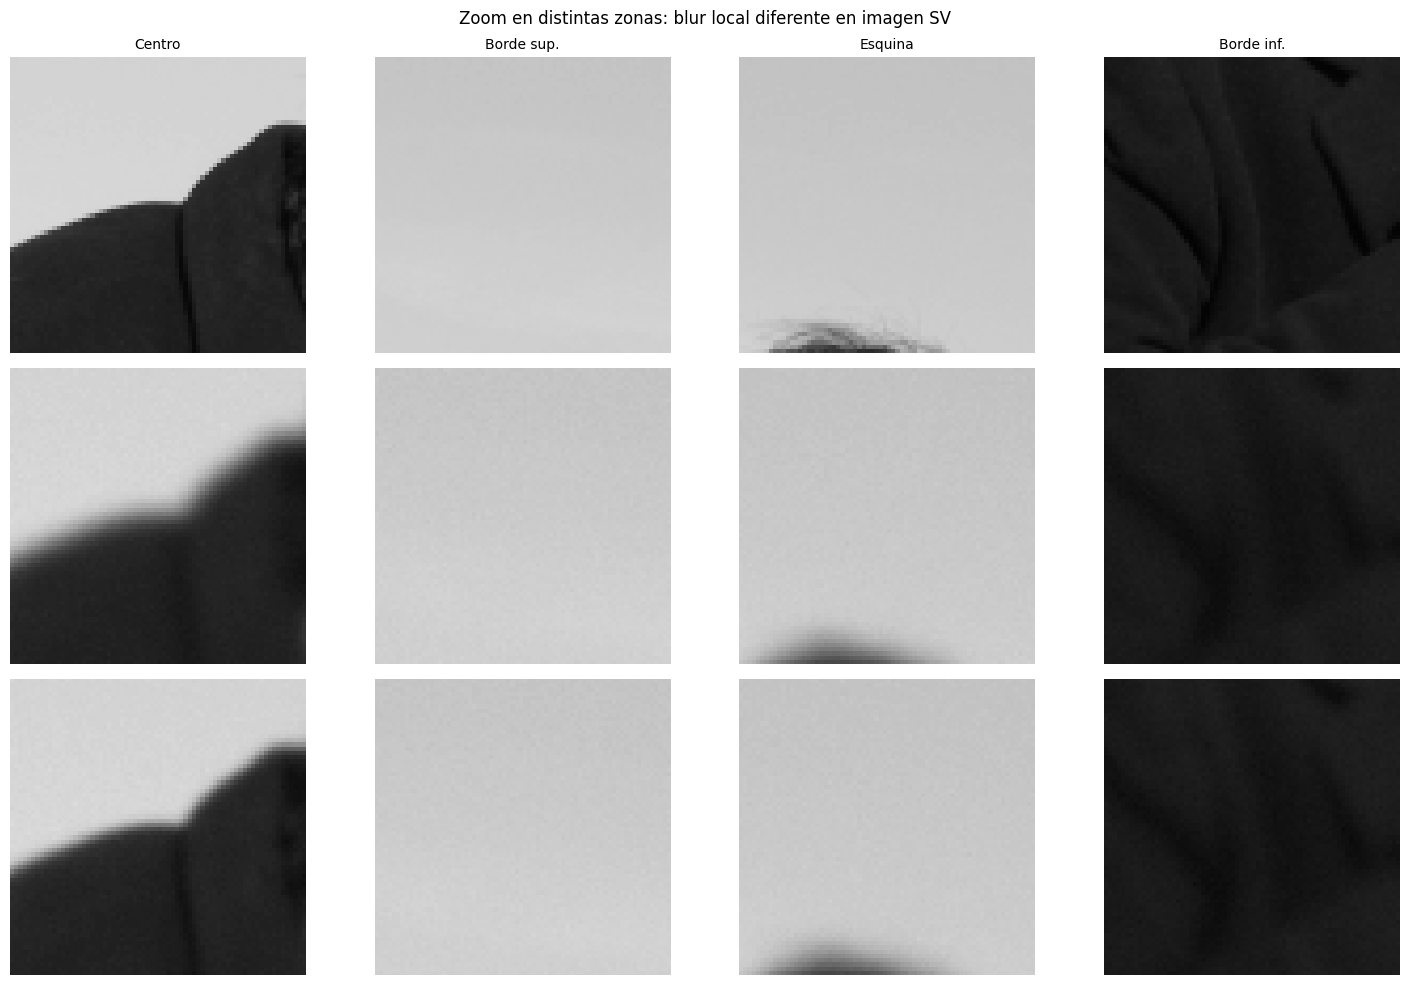

In [6]:
# ── Zoom en distintas zonas para comparar el blur local ─────────────────
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
zones = [
    ("Centro",      slice(90,160),  slice(90,160)),
    ("Borde sup.",  slice(0,70),    slice(90,160)),
    ("Esquina",     slice(0,70),    slice(185,255)),
    ("Borde inf.",  slice(185,255), slice(90,160)),
]

row_imgs = [img, g_si, g_sv]
row_labels = ["Original", "SI (σ uniforme)", "SV (σ variable)"]

for col, (label, sy, sx) in enumerate(zones):
    for row, (image, rlabel) in enumerate(zip(row_imgs, row_labels)):
        axes[row,col].imshow(image[sy,sx], vmin=0, vmax=1)
        if row == 0: axes[row,col].set_title(label, fontsize=10)
        if col == 0: axes[row,col].set_ylabel(rlabel, fontsize=9)
        axes[row,col].axis("off")

plt.suptitle("Zoom en distintas zonas: blur local diferente en imagen SV", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Restauración local: dividir en regiones y aplicar Wiener local

El enfoque más directo para restaurar una imagen SV es aplicar la lógica inversa
a la degradación por sectores:

1. Estimar (o conocer) la PSF local en cada sector
2. Aplicar el filtro de Wiener con esa PSF local
3. Mezclar los resultados con ventanas suaves

La calidad depende críticamente de:
- El número de sectores (más sectores → mejor aproximación, pero más costo)
- La suavidad del campo de PSF (si varía muy rápido, los sectores grandes introducen error)
- El solapamiento entre sectores (sin solapamiento hay artefactos en los bordes)


Restaurando con PSF conocida (SI vs SV)...


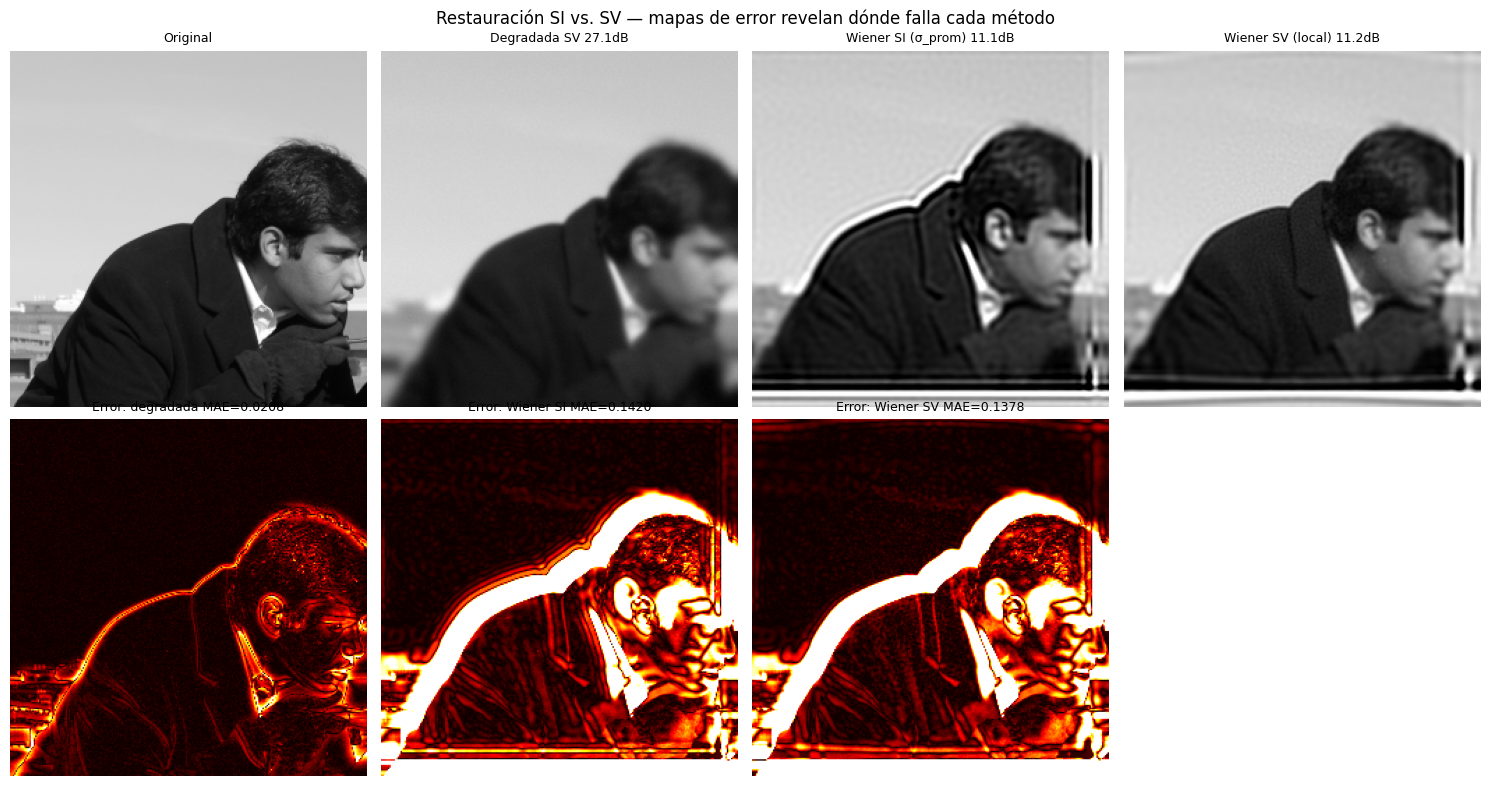

In [12]:
def sv_restore_wiener(g, sigma_field_map, psf_size=25, n_sectors=6, K=0.01):
    """
    Restauración SV por sectores: Wiener local + mezcla con ventana suave.
    """
    M, N = g.shape
    result = np.zeros_like(g)
    weight = np.zeros_like(g)

    ys = np.linspace(0, M-1, n_sectors+1, dtype=int)
    xs = np.linspace(0, N-1, n_sectors+1, dtype=int)

    for i in range(n_sectors):
        for j in range(n_sectors):
            cy = (ys[i]+ys[i+1])//2
            cx = (xs[j]+xs[j+1])//2
            sigma_local = sigma_field_map[cy, cx]
            h_local = gaussian_psf_2d(sigma_local, sigma_local, size=psf_size)

            # Filtro de Wiener local
            G = np.fft.fft2(g)
            H = np.fft.fft2(h_local, s=g.shape)
            H_conj = np.conj(H)
            F_hat = (H_conj * G) / (H_conj * H + K)
            f_local = np.clip(np.real(np.fft.ifft2(F_hat)), 0, 1)

            # Ventana suave
            win_y = np.exp(-0.5*((np.arange(M)-cy)/(M/n_sectors*0.7))**2)
            win_x = np.exp(-0.5*((np.arange(N)-cx)/(N/n_sectors*0.7))**2)
            win   = np.outer(win_y, win_x)

            result += f_local * win
            weight += win

    return np.clip(result / np.maximum(weight, 1e-10), 0, 1)

# ── Comparar restauraciones ───────────────────────────────────────────────
print("Restaurando con PSF conocida (SI vs SV)...")

# Restauración SI: usa sigma promedio para toda la imagen
h_mean = gaussian_psf_2d(sig_field.mean(), sig_field.mean(), size=25)
G = np.fft.fft2(g_sv)
H = np.fft.fft2(h_mean, s=g_sv.shape)
H_conj = np.conj(H)
f_si = np.clip(np.real(np.fft.ifft2((H_conj*G)/(H_conj*H+0.01))), 0, 1)

# Restauración SV local
f_sv = sv_restore_wiener(g_sv, sig_field, psf_size=25, n_sectors=8, K=0.01)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

images_top = [img, g_sv, f_si, f_sv]
titles_top = [
    "Original", f"Degradada SV {psnr(img,g_sv,data_range=1):.1f}dB",
    f"Wiener SI (σ_prom) {psnr(img,f_si,data_range=1):.1f}dB",
    f"Wiener SV (local) {psnr(img,f_sv,data_range=1):.1f}dB",
]
for ax, im, t in zip(axes[0], images_top, titles_top):
    ax.imshow(np.clip(im,0,1), vmin=0,vmax=1); ax.set_title(t, fontsize=9); ax.axis("off")

# Mapas de error
for ax, im, t in zip(axes[1],
    [g_sv, f_si, f_sv],
    ["Error: degradada", "Error: Wiener SI", "Error: Wiener SV"]):
    err = np.abs(im - img)
    ax.imshow(err, cmap="hot", vmin=0, vmax=0.3)
    ax.set_title(f"{t} MAE={err.mean():.4f}", fontsize=9)
    ax.axis("off")
axes[1,-1].axis("off")

plt.suptitle("Restauración SI vs. SV — mapas de error revelan dónde falla cada método",
             fontsize=12)
plt.tight_layout()
plt.show()


## 5. Restauración por interpolación de filtros de Wiener

Una mejora sobre la restauración por sectores es trabajar directamente
en el **dominio de la frecuencia**: interpolar los filtros de Wiener
calculados en posiciones de referencia.

La idea:
1. Calcular el filtro de Wiener $W_k(u,v)$ en $K$ posiciones de referencia $(x_k, y_k)$
2. Para cualquier posición $(x, y)$: interpolar los filtros de referencia
   usando pesos que dependen de la distancia a cada posición de referencia
3. Aplicar el filtro interpolado a la imagen en esa posición

$$
W(u,v; x,y) = \sum_k w_k(x,y) \cdot W_k(u,v)
$$

donde $w_k(x,y)$ son pesos de interpolación (por ejemplo, inversa de la distancia).

Este método es más suave que los sectores y evita los artefactos de borde.


Restaurando con interpolación de filtros de Wiener...


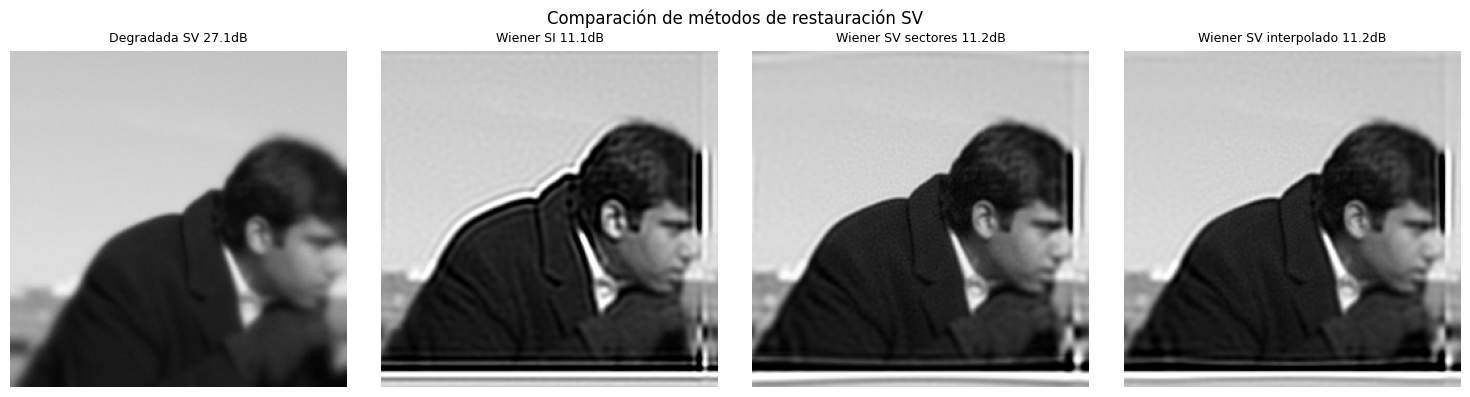

In [15]:
def wiener_filter(h, img_shape, K=0.01):
    """Calcula el filtro de Wiener en frecuencia."""
    H = np.fft.fft2(h, s=img_shape)
    H_conj = np.conj(H)
    return H_conj / (H_conj * H + K)

def sv_restore_interp(g, sigma_field_map, n_refs=4, psf_size=25, K=0.01):
    """
    Restauración SV por interpolación de filtros de Wiener.
    Usa n_refs x n_refs posiciones de referencia con interpolación IDW.
    """
    M, N = g.shape
    G = np.fft.fft2(g)

    # Posiciones de referencia en grid
    ref_y = np.linspace(M//8, 7*M//8, n_refs, dtype=int)
    ref_x = np.linspace(N//8, 7*N//8, n_refs, dtype=int)

    # Calcular filtros de Wiener en cada posición de referencia
    filters = {}
    for ry in ref_y:
        for rx in ref_x:
            s = sigma_field_map[ry, rx]
            h = gaussian_psf_2d(s, s, size=psf_size)
            filters[(ry,rx)] = wiener_filter(h, (M,N), K=K)

    # Para cada píxel, interpolar los filtros por IDW (Inverse Distance Weighting)
    # Lo hacemos en bloques para eficiencia
    result = np.zeros_like(g, dtype=complex)
    weight_total = np.zeros((M,N))

    yy, xx = np.mgrid[0:M, 0:N]

    for (ry,rx), W_ref in filters.items():
        dist = np.sqrt((yy-ry)**2 + (xx-rx)**2) + 1e-3
        w = 1.0 / dist**2    # IDW con exponente 2
        # Aplicar: resultado ponderado = W * G * w (en pixel space, broadcast)
        result_k = np.fft.ifft2(W_ref * G)
        result   += result_k * w[:,:,None].reshape(M,N,1).squeeze() if False else result_k * w
        weight_total += w

    result /= weight_total
    return np.clip(np.real(result), 0, 1)

print("Restaurando con interpolación de filtros de Wiener...")
f_sv_interp = sv_restore_interp(g_sv, sig_field, n_refs=5, psf_size=25, K=0.01)

p_sv_sec   = psnr(img, f_sv,        data_range=1)
p_sv_inter = psnr(img, f_sv_interp, data_range=1)

fig, axes = plt.subplots(1, 4, figsize=(15,4))
for ax, im, t in zip(axes,
    [g_sv, f_si, f_sv, f_sv_interp],
    [f"Degradada SV {psnr(img,g_sv,data_range=1):.1f}dB",
     f"Wiener SI {psnr(img,f_si,data_range=1):.1f}dB",
     f"Wiener SV sectores {p_sv_sec:.1f}dB",
     f"Wiener SV interpolado {p_sv_inter:.1f}dB"]):
    ax.imshow(np.clip(im,0,1), vmin=0,vmax=1); ax.set_title(t, fontsize=9); ax.axis("off")
plt.suptitle("Comparación de métodos de restauración SV", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Red neuronal para restauración SV (U-Net condicionada)

La limitación de los métodos clásicos SV es que requieren conocer el campo de PSF.
Una CNN puede aprender a restaurar imágenes SV **sin conocer explícitamente** la PSF.

### Arquitectura: U-Net condicionada por el campo de σ

La idea es dar a la red información adicional sobre la variación de la PSF.
Esto se implementa concatenando un **mapa de σ** como canal adicional de entrada:

```
Entrada: 2 canales
  ├── Canal 0: imagen degradada g(x,y)
  └── Canal 1: mapa normalizado de σ(x,y)   ← condicionamiento espacial

U-Net → f̂(x,y)
```

El mapa de σ actúa como una "pista espacial": le dice a la red cuánto blur
hay en cada zona, permitiéndole aplicar una restauración adaptativa.

Sin este canal extra, la red tiene que *adivinar* la variación local — tarea
mucho más difícil y con peores resultados.


In [16]:
if TORCH_AVAILABLE:
    # ── Dataset SV ────────────────────────────────────────────────────────
    class SVDataset(Dataset):
        """
        Pares (g_SV, mapa_sigma, f_limpia) generados sintéticamente.
        """
        def __init__(self, n=300, img_size=128,
                     sigma_center_range=(0.8, 2.0),
                     sigma_edge_range=(3.0, 7.0)):
            self.n = n
            self.size = img_size
            self.sc_range = sigma_center_range
            self.se_range = sigma_edge_range
            self.rng = np.random.default_rng(5)

        def __len__(self): return self.n

        def __getitem__(self, _):
            S = self.size
            rng = self.rng

            # Imagen sintética
            f = np.zeros((S, S), dtype=np.float32)
            for _ in range(rng.integers(3, 7)):
                r0, c0 = rng.integers(5, S//2, size=2)
                h_s = rng.integers(8, S-r0-5)
                w_s = rng.integers(8, S-c0-5)
                f[r0:r0+h_s, c0:c0+w_s] = float(rng.uniform(0.3, 1.0))

            # Campo de sigma aleatorio
            sc = float(rng.uniform(*self.sc_range))
            se = float(rng.uniform(*self.se_range))
            pow_ = float(rng.uniform(1.5, 3.0))
            sig_map = sigma_field(S, S, sc, se, pow_).astype(np.float32)

            # Degradar (simplificado: sectores 4×4)
            g = sv_degrade(f.astype(np.float64), sig_map.astype(np.float64),
                           psf_size=15, n_sectors=4, sigma_n=0.005).astype(np.float32)

            # Normalizar mapa de sigma a [0,1]
            sig_norm = ((sig_map - sig_map.min()) /
                        (sig_map.max() - sig_map.min() + 1e-6))

            # Input: 2 canales [g, sigma_norm]
            x = np.stack([g, sig_norm], axis=0)    # (2, S, S)
            y = f[None]                              # (1, S, S)
            return torch.from_numpy(x), torch.from_numpy(y)

    # ── U-Net condicionada (2 canales entrada) ────────────────────────────
    class DoubleConv(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            )
        def forward(self, x): return self.net(x)

    class SVUNet(nn.Module):
        """U-Net con 2 canales de entrada (imagen + mapa de sigma)."""
        def __init__(self, base=32):
            super().__init__()
            self.enc1 = DoubleConv(2, base)       # ← 2 canales entrada
            self.enc2 = DoubleConv(base,   base*2)
            self.enc3 = DoubleConv(base*2, base*4)
            self.pool = nn.MaxPool2d(2)
            self.bottleneck = DoubleConv(base*4, base*8)
            self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
            self.dec3 = DoubleConv(base*8, base*4)
            self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
            self.dec2 = DoubleConv(base*4, base*2)
            self.up1  = nn.ConvTranspose2d(base*2, base,   2, stride=2)
            self.dec1 = DoubleConv(base*2, base)
            self.out  = nn.Conv2d(base, 1, 1)

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            b  = self.bottleneck(self.pool(e3))
            d3 = self.dec3(torch.cat([self.up3(b),  e3], 1))
            d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
            d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
            return self.out(d1)

    sv_unet = SVUNet(base=32).to(device)
    n_par = sum(p.numel() for p in sv_unet.parameters())
    print(f"SVUNet parámetros: {n_par:,}")

    train_sv_ds = SVDataset(n=300)
    val_sv_ds   = SVDataset(n=60)
    train_sv_dl = DataLoader(train_sv_ds, batch_size=8, shuffle=True, num_workers=0)
    val_sv_dl   = DataLoader(val_sv_ds,   batch_size=8, num_workers=0)


SVUNet parámetros: 1,926,721


In [17]:
if TORCH_AVAILABLE:
    import time

    opt_sv    = optim.Adam(sv_unet.parameters(), lr=5e-4, weight_decay=1e-4)
    sched_sv  = optim.lr_scheduler.StepLR(opt_sv, step_size=15, gamma=0.3)
    crit_sv   = nn.MSELoss()

    EPOCHS_SV = 30
    train_losses_sv, val_psnrs_sv = [], []

    print(f"{'Epoch':>5} {'Train MSE':>12} {'Val PSNR':>10}")
    print("─" * 35)

    for epoch in range(1, EPOCHS_SV+1):
        sv_unet.train()
        train_loss = 0.0
        for x_b, y_b in train_sv_dl:
            x_b, y_b = x_b.to(device), y_b.to(device)
            opt_sv.zero_grad()
            y_hat = sv_unet(x_b)
            loss  = crit_sv(y_hat, y_b)
            loss.backward(); opt_sv.step()
            train_loss += loss.item() * x_b.size(0)
        train_loss /= len(train_sv_ds)

        sv_unet.eval()
        psnr_sum = 0.0
        with torch.no_grad():
            for x_b, y_b in val_sv_dl:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_hat = sv_unet(x_b).clamp(0,1)
                for b in range(y_hat.shape[0]):
                    psnr_sum += psnr(y_b[b,0].cpu().numpy(),
                                     y_hat[b,0].cpu().numpy(), data_range=1.0)
        val_psnr = psnr_sum / len(val_sv_ds)
        sched_sv.step()
        train_losses_sv.append(train_loss)
        val_psnrs_sv.append(val_psnr)

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>5}  {train_loss:>12.6f}  {val_psnr:>9.2f} dB")

    print("\n✔ Entrenamiento SVUNet completo.")


Epoch    Train MSE   Val PSNR
───────────────────────────────────
    1      0.039969      20.05 dB
    5      0.004784      25.93 dB
   10      0.003426      27.77 dB
   15      0.001989      28.96 dB
   20      0.001429      30.88 dB
   25      0.001202      31.71 dB
   30      0.001136      31.83 dB

✔ Entrenamiento SVUNet completo.


In [ ]:
if TORCH_AVAILABLE:
    # ── Evaluación cualitativa SVUNet vs. métodos clásicos ────────────────
    rng_vis = np.random.default_rng(77)

    # Generar un ejemplo de prueba nuevo
    f_test = np.zeros((128,128), dtype=np.float64)
    for _ in range(5):
        r0,c0 = rng_vis.integers(5,60,size=2)
        h_r,w_r = rng_vis.integers(15,60), rng_vis.integers(15,60)
        if r0+h_r<128 and c0+w_r<128:
            f_test[r0:r0+h_r, c0:c0+w_r] = float(rng_vis.uniform(0.3,1.0))

    sig_test = sigma_field(128, 128, sigma_center=1.2, sigma_edge=5.5, power=2)
    g_test   = sv_degrade(f_test, sig_test, psf_size=15, n_sectors=4, sigma_n=0.005)
    sig_norm_test = ((sig_test - sig_test.min()) /
                     (sig_test.max() - sig_test.min() + 1e-6)).astype(np.float32)

    # Restaurar con los tres métodos
    f_wiener_si   = np.clip(np.real(np.fft.ifft2(
        wiener_filter(gaussian_psf_2d(sig_test.mean(), sig_test.mean(), size=15),
                      g_test.shape, K=0.01) * np.fft.fft2(g_test))), 0, 1)
    f_sv_sec_test = sv_restore_wiener(g_test, sig_test, psf_size=15, n_sectors=6, K=0.01)

    sv_unet.eval()
    with torch.no_grad():
        x_t = torch.from_numpy(np.stack([g_test.astype(np.float32),
                                          sig_norm_test])[None]).to(device)
        f_sv_cnn = sv_unet(x_t)[0,0].cpu().numpy().clip(0,1)

    imgs_eval = [f_test, g_test, f_wiener_si, f_sv_sec_test, f_sv_cnn]
    titles_eval = [
        "Original",
        f"Degradada SV
{psnr(f_test,g_test,data_range=1):.1f}dB",
        f"Wiener SI
{psnr(f_test,f_wiener_si,data_range=1):.1f}dB",
        f"Wiener SV sectores
{psnr(f_test,f_sv_sec_test,data_range=1):.1f}dB",
        f"SVUNet (CNN)
{psnr(f_test,f_sv_cnn,data_range=1):.1f}dB",
    ]

    fig, axes = plt.subplots(1, 5, figsize=(17,4))
    for ax, im, t in zip(axes, imgs_eval, titles_eval):
        ax.imshow(np.clip(im,0,1), vmin=0,vmax=1)
        ax.set_title(t, fontsize=9); ax.axis("off")
    plt.suptitle("Restauración SV: SI vs. Sectores vs. CNN condicionada", fontsize=12)
    plt.tight_layout()
    plt.show()


## 7. Estimación del campo de PSF desde la imagen

En la práctica no conocemos $\sigma(x,y)$. Tenemos que **estimarlo** desde $g$.

### Estrategia: estimación local del blur

En cada región pequeña de la imagen, estimamos el nivel de blur local
usando la **energía de los gradientes**: una región borrosa tiene
gradientes más débiles que una región nítida.

$$
\text{blur}_\text{local}(x,y) \propto \frac{1}{\text{varianza local de gradientes}}
$$

Esto da una estimación gruesa pero rápida del campo de PSF sin necesidad
de resolver un problema de optimización.

Una estimación más precisa usa el **espectro local de potencia**
(calculado en ventanas deslizantes) comparado con el modelo espectral
de imágenes naturales — exactamente como hicimos en el Cap. 5 Sección 2,
pero aplicado localmente.


In [ ]:
def estimate_sigma_field_from_gradient(g, window_size=32, step=16):
    """
    Estimación del campo de sigma usando la varianza local del gradiente.
    Zonas con blur alto → gradiente débil → sigma estimado alto.
    """
    M, N = g.shape
    # Gradiente de la imagen
    gx = np.diff(g, axis=1, prepend=g[:,:1])
    gy = np.diff(g, axis=0, prepend=g[:1,:])
    grad_mag = np.sqrt(gx**2 + gy**2)

    # Varianza local del gradiente (blur local)
    sigma_map_est = np.zeros((M, N))
    count_map     = np.zeros((M, N))

    ys = range(0, M-window_size+1, step)
    xs = range(0, N-window_size+1, step)

    for y0 in ys:
        for x0 in xs:
            patch_grad = grad_mag[y0:y0+window_size, x0:x0+window_size]
            var_grad = patch_grad.var() + 1e-8
            # Sigma estimado: inversamente proporcional a la varianza del gradiente
            sigma_est = 1.0 / np.sqrt(var_grad) * 0.3   # escalar empírico
            sigma_est = np.clip(sigma_est, 0.5, 8.0)

            sigma_map_est[y0:y0+window_size, x0:x0+window_size] += sigma_est
            count_map[y0:y0+window_size, x0:x0+window_size]     += 1.0

    sigma_map_est /= np.maximum(count_map, 1)
    # Suavizar el mapa estimado
    sigma_map_est = gaussian_filter(sigma_map_est, sigma=window_size//4)
    return sigma_map_est

# ── Aplicar a la imagen degradada SV ─────────────────────────────────────
sigma_est_field = estimate_sigma_field_from_gradient(g_sv, window_size=32, step=8)

# Normalizar escala para comparar con campo real
# (la estimación es relativa, no absoluta)
scale = sig_field.mean() / (sigma_est_field.mean() + 1e-6)
sigma_est_field_scaled = np.clip(sigma_est_field * scale, 0.5, 8.0)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(g_sv, vmin=0, vmax=1); axes[0].set_title("Imagen degradada SV"); axes[0].axis("off")

im1 = axes[1].imshow(sig_field, cmap="plasma", vmin=0, vmax=7)
axes[1].set_title("Campo σ REAL"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(sigma_est_field_scaled, cmap="plasma", vmin=0, vmax=7)
axes[2].set_title("Campo σ ESTIMADO
(varianza de gradiente)"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2])

err_campo = np.abs(sig_field - sigma_est_field_scaled)
im3 = axes[3].imshow(err_campo, cmap="hot", vmin=0, vmax=3)
axes[3].set_title(f"Error del campo estimado
MAE={err_campo.mean():.2f}px"); axes[3].axis("off")
plt.colorbar(im3, ax=axes[3])

plt.suptitle("Estimación del campo de PSF desde los gradientes de la imagen", fontsize=12)
plt.tight_layout()
plt.show()

# ── Restaurar con campo estimado vs. campo real ───────────────────────────
f_sv_real_field = sv_restore_wiener(g_sv, sig_field,              n_sectors=8, K=0.01)
f_sv_est_field  = sv_restore_wiener(g_sv, sigma_est_field_scaled, n_sectors=8, K=0.01)

print(f"Wiener SV con campo REAL:     PSNR={psnr(img,f_sv_real_field,data_range=1):.2f}dB")
print(f"Wiener SV con campo ESTIMADO: PSNR={psnr(img,f_sv_est_field, data_range=1):.2f}dB")


## 8. Caso de uso: corrección de aberraciones en campo amplio

Simulamos un sistema de imagen de campo amplio realista donde:

- La PSF es prácticamente difraction-limited en el centro ($\sigma \approx 1$ px)
- Crece con el cuadrado del ángulo de campo (aberración de Seidel)
- Desarrolla astigmatismo que rota con la posición angular
- En los bordes la PSF puede ser 5-8× más grande que en el centro

Este es el escenario típico de un **telescopio de campo amplio** o una
**cámara DSLR con lente de gama media** fotografiando estrellas.


In [ ]:
# ── Simular campo estelar con PSF variable ────────────────────────────────
np.random.seed(7)
IMG_SIZE = 256

# Campo estelar: puntos brillantes (fuentes puntuales) en posiciones aleatorias
f_stars = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float64)
n_stars = 80
star_positions = np.random.randint(5, IMG_SIZE-5, size=(n_stars, 2))
star_magnitudes = np.random.exponential(0.3, n_stars)
star_magnitudes = np.clip(star_magnitudes, 0.05, 1.0)

for (sy, sx), mag in zip(star_positions, star_magnitudes):
    f_stars[sy, sx] = mag

# Campo de PSF: gaussiana + astigmatismo creciente con el radio
def wide_field_psf_at(py, px, img_size=IMG_SIZE, sigma_center=1.0, sigma_edge=6.0):
    """PSF del sistema en la posición (py, px)."""
    cy, cx = img_size//2, img_size//2
    r = np.sqrt(((py-cy)/cy)**2 + ((px-cx)/cx)**2)   # radio normalizado
    sigma_radial = sigma_center + (sigma_edge-sigma_center)*r**2
    astig = 1.5 * r**2
    theta = np.rad2deg(np.arctan2(py-cy, px-cx))
    return gaussian_psf_2d(sigma_radial+astig, sigma_radial, theta, size=31)

# Degradación correcta estrella a estrella
print("Degradando campo estelar (SV)...")
g_stars = np.zeros_like(f_stars)
for (sy, sx), mag in zip(star_positions, star_magnitudes):
    h_local = wide_field_psf_at(sy, sx)
    # Cada estrella se convierte en su PSF local
    half = h_local.shape[0]//2
    y0,y1 = max(0,sy-half), min(IMG_SIZE,sy+half+1)
    x0,x1 = max(0,sx-half), min(IMG_SIZE,sx+half+1)
    hy0,hy1 = half-(sy-y0), half+(y1-sy)
    hx0,hx1 = half-(sx-x0), half+(x1-sx)
    g_stars[y0:y1, x0:x1] += mag * h_local[hy0:hy1, hx0:hx1]

g_stars = np.clip(g_stars + np.random.normal(0, 0.003, g_stars.shape), 0, 1)

# ── Campo de sigma para restauración ─────────────────────────────────────
sig_wf = sigma_field(IMG_SIZE, IMG_SIZE, sigma_center=1.0, sigma_edge=6.0, power=2)

# Restauración SV vs SI
f_si_stars = np.clip(np.real(np.fft.ifft2(
    wiener_filter(gaussian_psf_2d(sig_wf.mean(), sig_wf.mean(), size=31),
                  g_stars.shape, K=0.005) * np.fft.fft2(g_stars))), 0, 1)

f_sv_stars = sv_restore_wiener(g_stars, sig_wf, psf_size=31, n_sectors=8, K=0.005)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles_row = ["Original (estrellas)", "Degradado SV
(campo amplio)", 
              "Restaurado SI", "Restaurado SV"]

for ax, im, t in zip(axes[0], [f_stars, g_stars, f_si_stars, f_sv_stars][:3],
                               ["Original", "Degradado SV", "Restaurado SI"]):
    ax.imshow(np.clip(im,0,1)**0.5, cmap="gray")   # gamma para ver estrellas débiles
    ax.set_title(t, fontsize=10); ax.axis("off")

axes[0,2].imshow(np.clip(f_sv_stars,0,1)**0.5, cmap="gray")
axes[0,2].set_title("Restaurado SV", fontsize=10); axes[0,2].axis("off")

# Zoom en centro vs. borde
for col, (label, sy, sx) in enumerate([
    ("Centro (PSF pequeña)", slice(100,156), slice(100,156)),
    ("Borde (PSF grande)",   slice(0,56),    slice(0,56)),
    ("Comparación SV",       slice(0,56),    slice(0,56)),
]):
    ref  = f_stars[sy,sx]**0.5
    deg  = g_stars[sy,sx]**0.5
    rest = (f_sv_stars[sy,sx] if col==2 else f_si_stars[sy,sx])**0.5

    comparison = np.hstack([deg, rest])
    axes[1,col].imshow(comparison, cmap="gray")
    axes[1,col].set_title(
        f"{label}\n{'Degradado | Wiener SV' if col==2 else 'Degradado | Wiener SI'}",
        fontsize=8)
    axes[1,col].axis("off")
    axes[1,col].axvline(56, color="yellow", linewidth=1, alpha=0.7)

plt.suptitle("Caso de uso: campo estelar — PSF varía del centro al borde", fontsize=12)
plt.tight_layout()
plt.show()

print(f"PSNR restauración SI: {psnr(f_stars, f_si_stars, data_range=1):.2f}dB")
print(f"PSNR restauración SV: {psnr(f_stars, f_sv_stars, data_range=1):.2f}dB")


## 9. Ejercicios sugeridos

1. **Número de sectores**: en `sv_restore_wiener`, varía `n_sectors` entre 2, 4, 8
   y 16. Grafica PSNR vs. tiempo de ejecución. ¿Cuál es el punto óptimo
   para la imagen de prueba?

2. **Campo de PSF discontinuo**: modifica `sigma_field` para crear un campo
   con un salto abrupto (por ejemplo, un defocus diferente en la mitad izquierda
   y derecha de la imagen). ¿Cómo afecta esto a los métodos de restauración?
   ¿Qué tamaño de sector es necesario para manejar la discontinuidad?

3. **SVUNet sin mapa de sigma**: entrena una segunda versión de `SVUNet` con
   solo 1 canal de entrada (solo $g$, sin el mapa de $\sigma$).
   Compara el PSNR con la versión condicionada. ¿Cuánto ayuda el mapa?

4. **Estimación de campo más precisa**: mejora `estimate_sigma_field_from_gradient`
   usando el espectro local de potencia en ventanas de 32×32 px con paso 16.
   Calcula el MAE del campo estimado vs. el real.

5. **Astigmatismo puro**: modifica `sv_degrade` para usar PSFs con
   $\sigma_x \neq \sigma_y$ y rotación variable según `astig_field`.
   Implementa la restauración con `sv_restore_wiener` pasando $\sigma_x$
   y $\sigma_y$ separados. ¿Mejora respecto a usar solo $\sigma$ isotrópico?

6. **EigenPSF**: calcula la descomposición SVD del conjunto de PSFs en un grid
   5×5 de la imagen. Los vectores singulares dominantes son las "eigenPSFs".
   Muestra cuántas eigenPSFs se necesitan para aproximar el campo con error < 5%.


## 10. Conclusiones

Los sistemas espacio-variantes son la regla en la óptica real,
no la excepción. Este capítulo establece las herramientas fundamentales
para tratarlos.

### Resumen de métodos

| Método | Complejidad | Requiere campo de PSF | Calidad |
|---|---|---|---|
| **Wiener SI** (σ promedio) | O(N² log N) | No (una PSF) | Pobre en bordes |
| **Sectores + Wiener local** | O(S² · N² log N) | Sí (en grid) | Buena si S suficiente |
| **Interpolación de filtros** | O(K² · N²) | Sí (en K puntos) | Suave, sin artefactos |
| **SVUNet condicionada** | O(N² · parámetros) | Sí (mapa normalizado) | Muy buena en dominio |
| **SVUNet sin condición** | O(N² · parámetros) | No | Buena si entrenada con diversidad |

### Ideas clave

- La **aproximación local** (LSI) es válida cuando el campo de PSF varía suavemente.
- Las **ventanas suaves** entre sectores son esenciales para evitar artefactos.
- El **condicionamiento espacial** (pasar el mapa de σ como canal extra) mejora
  significativamente las CNNs para restauración SV.
- La **estimación del campo de PSF** desde los gradientes locales es una primera
  aproximación rápida; para precisión se necesitan métodos más sofisticados.
- En astronomía, la **Óptica Adaptativa** corrige la PSF en tiempo real usando
  espejos deformables — el equivalente hardware de lo que aquí hacemos en software.

---

### Próximo notebook

**Capítulo 7 — Métricas de Calidad de Imagen: más allá del PSNR**  
PSNR y SSIM miden el error píxel a píxel, pero no siempre correlacionan con
la percepción humana. Veremos métricas perceptuales (LPIPS, FSIM, BRISQUE)
y cómo usarlas para evaluar y entrenar sistemas de restauración.
